In [510]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import scipy
from scipy.stats import f_oneway, ttest_rel
from pathlib import Path
import os
from PIL import Image

In [512]:
root_dir = '.'
csv_list = list(Path(root_dir).glob("_data*.csv"))
csv_list.sort()
print(csv_list)
df_list_all = {}
for csv in csv_list:
    csv_stem = '_'.join(csv.stem.split('_')[:-2])
    df_list_all[csv_stem] = pd.read_csv(csv)

df_list_all['_123_edge1'] = df_list_all['_data_edge1'].copy()
df_list_all['_123_edge5'] = df_list_all['_data_edge5'].copy()
df_list_all['_123_unet1'] = df_list_all['_data_all_tests_test1_epoch3'].copy()
df_list_all['_123_unet3'] = df_list_all['_data_all_tests_test3_epoch3'].copy()
df_list_all['_123_unet5'] = df_list_all['_data_all_tests_test5_epoch3'].copy()
print()
print(df_list_all.keys())

[WindowsPath('_data_all_tests_test1_epoch1_20260409_101948.csv'), WindowsPath('_data_all_tests_test1_epoch2_20260409_103108.csv'), WindowsPath('_data_all_tests_test1_epoch3_20260410_124634.csv'), WindowsPath('_data_all_tests_test1_epoch5_20260410_125151.csv'), WindowsPath('_data_all_tests_test1_epoch6_20260410_125722.csv'), WindowsPath('_data_all_tests_test1_epoch8_20260410_130226.csv'), WindowsPath('_data_all_tests_test3_epoch1_20260409_094349.csv'), WindowsPath('_data_all_tests_test3_epoch1_20260410_130736.csv'), WindowsPath('_data_all_tests_test3_epoch2_20260409_095310.csv'), WindowsPath('_data_all_tests_test3_epoch2_20260410_131255.csv'), WindowsPath('_data_all_tests_test3_epoch3_20260409_095717.csv'), WindowsPath('_data_all_tests_test3_epoch3_20260410_131631.csv'), WindowsPath('_data_all_tests_test5_epoch1_20260410_132011.csv'), WindowsPath('_data_all_tests_test5_epoch2_20260410_132348.csv'), WindowsPath('_data_all_tests_test5_epoch3_20260410_132723.csv'), WindowsPath('_data_DATA_

In [513]:
def merge_df(_df_keys):
    _df_keys = ['_data_DATA_FINAL_test_input'] + _df_keys
    _df_list = [ df_list_all[f][['source','match_norm']].rename(columns={'match_norm':f.split('_')[-1]}) for f in _df_keys]
    _df_merged = _df_list[0]
    for _df in _df_list[1:]:
        _df_merged = pd.merge(_df_merged, _df, on="source")
        if len(_df)!=len(_df_merged):
            print('ERROR: incomplete merge', _df.columns)    
    #print(_df_merged.columns)
    for c in _df_merged.columns[2:]:
        _df_merged['pair-input-' + c] = _df_merged[c] - _df_merged.input
    print(_df_merged.columns)
    return _df_merged

In [623]:
_df_keys =  ['_data_all_tests_test1_epoch8', '_data_all_tests_test5_epoch3']
df_18_35 = merge_df(_df_keys)

Index(['source', 'input', 'epoch8', 'epoch3', 'pair-input-epoch8',
       'pair-input-epoch3'],
      dtype='object')


In [514]:
target = '123'
_df_keys =  list(filter(lambda x: target in x, df_list_all.keys()))
df_all_merged = merge_df(_df_keys)

Index(['source', 'input', 'edge1', 'edge5', 'unet1', 'unet3', 'unet5',
       'pair-input-edge1', 'pair-input-edge5', 'pair-input-unet1',
       'pair-input-unet3', 'pair-input-unet5'],
      dtype='object')


In [515]:
target = 'target'
_df_keys = list(filter(lambda x: target in x, df_list_all.keys())) 
df_bob_merged = merge_df(_df_keys)

Index(['source', 'input', 'target', 'pair-input-target'], dtype='object')


In [564]:
target = 'test1'
_df_keys = list(filter(lambda x: target in x, df_list_all.keys()))
df_test1_merged = merge_df(_df_keys)

Index(['source', 'input', 'epoch1', 'epoch2', 'epoch3', 'epoch5', 'epoch6',
       'epoch8', 'pair-input-epoch1', 'pair-input-epoch2', 'pair-input-epoch3',
       'pair-input-epoch5', 'pair-input-epoch6', 'pair-input-epoch8'],
      dtype='object')


In [516]:
target = 'test3'
_df_keys = list(filter(lambda x: target in x, df_list_all.keys()))
df_test3_merged = merge_df(_df_keys)

Index(['source', 'input', 'epoch1', 'epoch2', 'epoch3', 'pair-input-epoch1',
       'pair-input-epoch2', 'pair-input-epoch3'],
      dtype='object')


In [517]:
target = 'test5'
_df_keys = list(filter(lambda x: target in x, df_list_all.keys()))
df_test5_merged = merge_df(_df_keys)

Index(['source', 'input', 'epoch1', 'epoch2', 'epoch3', 'pair-input-epoch1',
       'pair-input-epoch2', 'pair-input-epoch3'],
      dtype='object')


In [634]:
def min_max(x, xlim):
    mu0 = x.mean()
    sd0 = x.std(ddof=1)
    xlim[0] = min(xlim[0], min(x),mu0-1*sd0)
    xlim[1] = max(xlim[1], max(x),mu0+1*sd0)

def bin(df, columns):
    values = set()
    xlim=[0,0]
    for column in columns:
        values |= set(df[column].unique())
        min_max(df[column], xlim)
    #print(values)
    nrof_bins = len(values)+1
    if nrof_bins>13:
        nrof_bins=13
    bins = np.linspace(min(values), max(values), nrof_bins)
    return bins, xlim

def stylized(x, color, label, bins, xlim, factor):
    #plt.hist(x, bins, alpha=0.5, label=label)
    mu0 = x.mean()
    sd0 = x.std(ddof=1)
    print(f"\\textit{{{label}}} & {mu0:.2f} & {sd0:.2f} \\\\")
    x = np.linspace(*xlim,100)
    factor = len(x)/len(bins) * factor
    y0 = scipy.stats.norm.pdf(x,mu0,sd0) * factor
    plt.plot(x,y0,color,linestyle='dashed',linewidth=0.8, label=label)

def histo(df, columns, factor, manual_xlim=None, with_stylized=True, with_histo=True, filename='histo'):
    plt.rc('figure', figsize=(6, 3))
    if with_histo:
        bins,xlim = bin(df, columns)
        plt.hist([df[column] for column in columns], bins, alpha=0.5, label=[column for column in columns])
    else:
        bins, xlim = [1], [-0.09, 1.09]
        factor = 1.0 / len(df)
    if not manual_xlim is None:
        xlim = manual_xlim
    if with_stylized:
        for column,color in zip(columns,mcolors.TABLEAU_COLORS):
            if with_histo:
                stylized_labels=None
            else:
                stylized_labels=column
            stylized(df[column], color, label=stylized_labels, bins=bins, xlim=xlim, factor=factor)


    plt.xlim(xlim)
    plt.legend() #loc='upper left')
    plt.xlabel('match coefficient')
    plt.grid(visible=True)
    ax = plt.gca()
    ax.spines['left'].set_visible(True)   # Show left spine (y-axis line)
    ax.spines['bottom'].set_visible(True) # Show bottom spine (x-axis line)
    
    # Hide the y-axis tick labels
    if with_histo is False:
        ax.set_yticklabels([])  # Hide y-axis values
    
    # Optionally, hide the y-axis ticks (the small lines)
    ax.yaxis.set_ticks_position('none')
    
    plt.savefig(filename + '.png', bbox_inches='tight')
    plt.show()

def ttest(df, left, right, with_debug=False):
    reference=0
    diff = 'pair-' + left + '-' + right
    t_statistic, p_value = scipy.stats.ttest_1samp(df[diff], popmean=reference,alternative='greater')
    if with_debug: 
        print(t_statistic, p_value)
    
    print(f"\\textit{{{right}}} & {t_statistic:.2f} & {p_value:.2f} \\\\")

    t_statistic, p_value = scipy.stats.ttest_rel(df[left], df[right],alternative='less')
    if with_debug: 
        print(t_statistic, p_value)
    


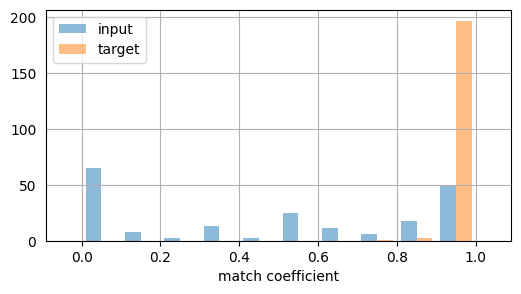

failing targets:
            source     input    target  pair-input-target
104    mice_007470  0.000000  0.750000           0.750000
106  monroe_007576  0.166667  0.833333           0.666667
107  monroe_007577  0.333333  0.833333           0.500000


In [583]:
columns = df_bob_merged.columns[1:len(df_bob_merged.columns)//2+1] 

histo(df_bob_merged, columns, manual_xlim=[-0.09, 1.09], with_stylized=False, with_histo=True, factor=5, filename='histo_target')
print('failing targets:')
print(df_bob_merged[df_bob_merged.target<1])

\textit{input} & 0.48 & 0.40 \\
\textit{epoch1} & 0.76 & 0.28 \\
\textit{epoch2} & 0.88 & 0.20 \\
\textit{epoch3} & 0.89 & 0.21 \\
\textit{epoch5} & 0.91 & 0.15 \\
\textit{epoch6} & 0.94 & 0.13 \\
\textit{epoch8} & 0.96 & 0.11 \\


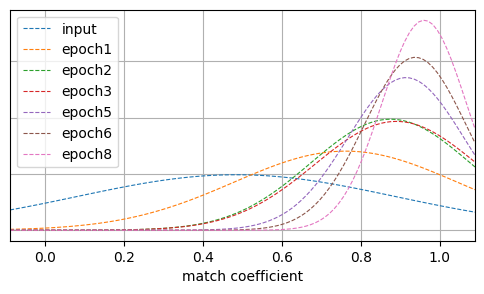

In [592]:
columns = df_test1_merged.columns[1:len(df_test1_merged.columns)//2+1]

histo(df_test1_merged, columns, with_histo=False, factor=4, filename='histo_test1')

\textit{input} & 0.48 & 0.40 \\
\textit{edge1} & 0.12 & 0.22 \\
\textit{edge5} & 0.10 & 0.24 \\
\textit{unet1} & 0.89 & 0.21 \\
\textit{unet3} & 0.93 & 0.15 \\
\textit{unet5} & 0.98 & 0.08 \\


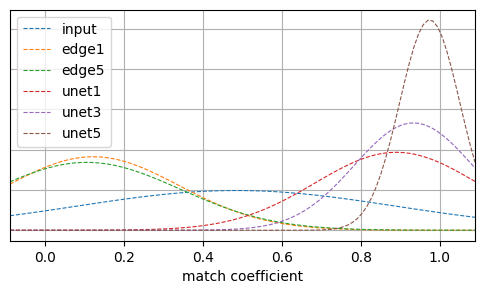

In [600]:
columns = df_all_merged.columns[1:len(df_all_merged.columns)//2+1]

histo(df_all_merged, columns, with_histo=False, factor=4, filename='histo_all_epoch3')

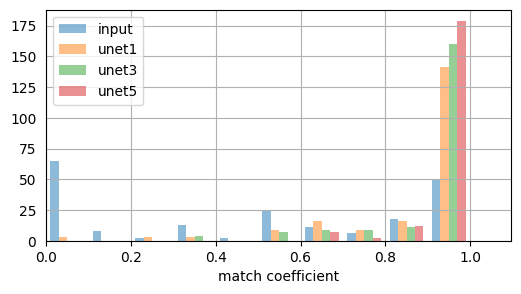

In [601]:
columns = [ 'input', 'unet1', 'unet3',  'unet5', ]

histo(df_all_merged, columns, factor=3, with_stylized=False, filename='histo_epoch3')

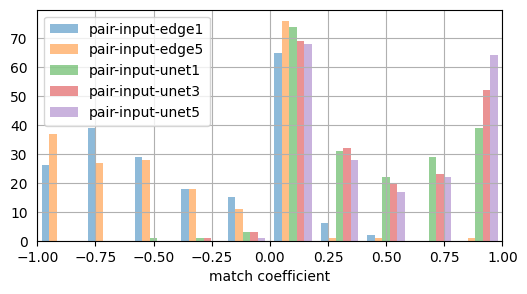

\textit{edge1} & -13.24 & 1.00 \\
\textit{edge5} & -13.40 & 1.00 \\
\textit{unet1} & 15.39 & 0.00 \\
\textit{unet3} & 16.67 & 0.00 \\
\textit{unet5} & 17.68 & 0.00 \\


In [602]:
columns = df_all_merged.columns[len(df_all_merged.columns)//2+1:]

histo(df_all_merged, columns, factor=4, with_stylized=False, filename='histo_all_ttest')
ttest(df_all_merged, 'input','edge1')
ttest(df_all_merged, 'input','edge5')
ttest(df_all_merged, 'input','unet1')
ttest(df_all_merged, 'input','unet3')
ttest(df_all_merged, 'input','unet5')


In [603]:
columns = [ 'input', 'epoch1', 'epoch2',  'epoch3', ]

#histo(df_test5_merged, columns, with_histo=False, factor=4, filename='histo_test5')

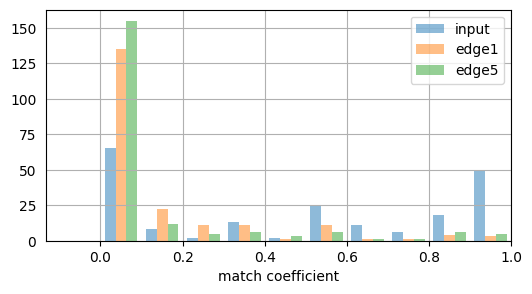

In [604]:
columns = [ 'input',  'edge1',  'edge5', ]

histo(df_all_merged, columns, factor=4, with_stylized=False, filename='histo_edge')

\textit{None} & 0.41 & 0.37 \\
\textit{None} & 0.45 & 0.38 \\
\textit{None} & 0.49 & 0.39 \\


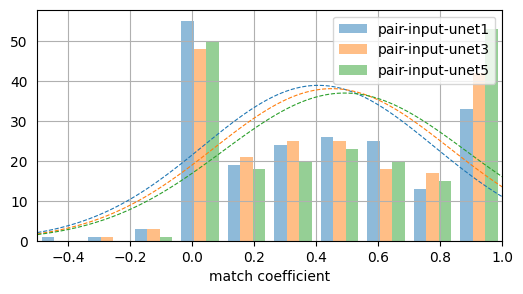

\textit{unet1} & 15.39 & 0.00 \\
\textit{unet3} & 16.67 & 0.00 \\
\textit{unet5} & 17.68 & 0.00 \\


In [605]:
columns = [ 'pair-input-unet1',  'pair-input-unet3',  'pair-input-unet5', ]
histo(df_all_merged, columns, factor=4, with_stylized=True, filename='histo_unet_ttest')
ttest(df_all_merged, 'input','unet1')
ttest(df_all_merged, 'input','unet3')
ttest(df_all_merged, 'input','unet5')

\textit{None} & -0.36 & 0.39 \\
\textit{None} & -0.38 & 0.40 \\


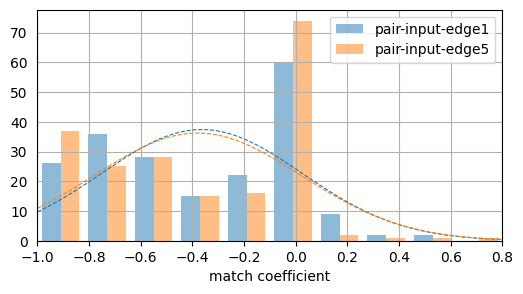

\textit{edge1} & -13.24 & 1.00 \\
\textit{edge5} & -13.40 & 1.00 \\


In [606]:
columns = [ 'pair-input-edge1',  'pair-input-edge5', ]
histo(df_all_merged, columns, factor=4, with_stylized=True, filename='histo_edge_ttest')
ttest(df_all_merged, 'input','edge1')
ttest(df_all_merged, 'input','edge5')

\textit{None} & -0.08 & 0.19 \\
\textit{None} & -0.04 & 0.13 \\
\textit{None} & -0.04 & 0.18 \\


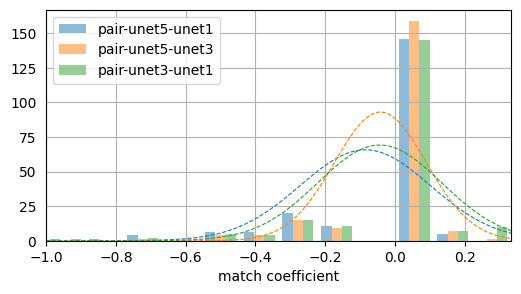

-6.4217186344480615 0.9999999995150632
\textit{unet1} & -6.42 & 1.00 \\
6.4217186344480615 0.9999999995150632
\textit{unet1} & -3.46 & 1.00 \\
\textit{unet3} & -4.44 & 1.00 \\


In [643]:
df_pair=df_all_merged.copy()
df_pair['pair-unet5-unet1']=df_pair.unet1-df_pair.unet5
df_pair['pair-unet5-unet3']=df_pair.unet3-df_pair.unet5
df_pair['pair-unet3-unet1']=df_pair.unet1-df_pair.unet3

columns = [ 'pair-unet5-unet1',  'pair-unet5-unet3', 'pair-unet3-unet1',  ]
histo(df_pair, columns, factor=4, with_stylized=True, filename='histo_unet_pair_ttest')
ttest(df_pair, 'unet5','unet1',with_debug=True)
ttest(df_pair, 'unet3','unet1')
ttest(df_pair, 'unet5','unet3')


Index(['source', 'input', 'epoch8', 'epoch3', 'pair-input-epoch8',
       'pair-input-epoch3', 'pair-epoch8-epoch3', 'pair-epoch3-epoch8'],
      dtype='object')
\textit{None} & 0.96 & 0.11 \\
\textit{None} & 0.98 & 0.08 \\


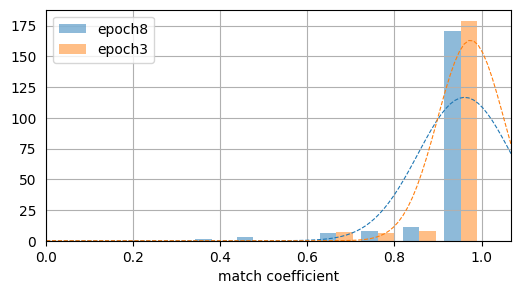

\textit{None} & 0.01 & 0.10 \\


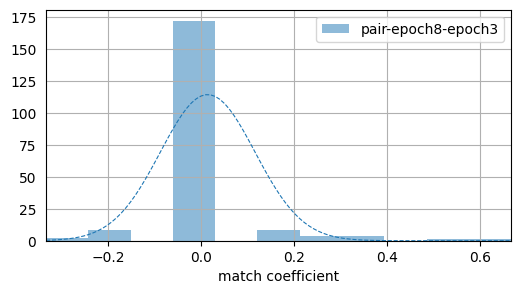

1.96708089638172 0.02528183521069991
\textit{epoch3} & 1.97 & 0.03 \\
-1.96708089638172 0.02528183521069991


In [645]:
df_18_35['pair-epoch8-epoch3']=+df_18_35.epoch3-df_18_35.epoch8
#df_18_35['pair-epoch3-epoch8']=+df_18_35.epoch8-df_18_35.epoch3
print(df_18_35.columns)

columns = [ 'epoch8',  'epoch3' ]
histo(df_18_35, columns, factor=2.5, with_stylized=True, filename='histo_18_35')
columns = [ 'pair-epoch8-epoch3' ]
histo(df_18_35, columns, factor=3.5, with_stylized=True, filename='histo_18_35_pair')
#ttest(df_18_35,'epoch3', 'epoch8',with_debug=True)
ttest(df_18_35,'epoch8', 'epoch3',with_debug=True)


(256, 256) 



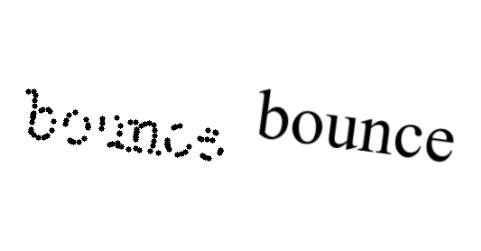

In [535]:
def merge_jpg(jpgs, name, nrof_cols=1):
    for i,c in enumerate(jpgs):
        img0 = Image.open(c)
        if i==0:
            size_x, size_y = img0.size
            img2 = Image.new("RGB", (nrof_cols * size_x, len(jpgs) // nrof_cols * size_y), "white")
            print(img0.size,'\n')
        
        img1 = img0.resize((size_x, size_y))
        img2.paste(img1, ((i%nrof_cols)* size_x, (i//nrof_cols)* size_y))
    
    plt.axis('off')
    plt.imshow(img2)
    img2.save(name + '.png')

jpgs = [r'D:\NonVersioned\DataScience\im1102\data\DATA_FINAL\test_input\bounce_007560_input.png', 
        r'D:\NonVersioned\DataScience\im1102\data\DATA_FINAL\test_target\bounce_007560_target.png']
merge_jpg(jpgs,'bounce', nrof_cols=2)